# Testing OT on simple contact matrices
Now that we have a feeling for OT values and other parameters important to OT, we'll test simple contact matrices to valid the approach used before.

## Function to generate simple contact matrices
To test simple contact matrices, we first need to write a function to generate them. For this, we need the function to:
- Generate a base contact map of a particular size and total weight.
- Take an argument that defines the 'distance'/overlap between two contact matrices.
- Generate another contact matrix with the desired overlap.

In [1]:
### Creating functions ###
import numpy as np
import matplotlib.pyplot as plt

def generate_contact_map(size: int = 10, total_reads: int = 2000, decay_rate: float = 0.2, 
                         noise_level: float = 0.1, seed: int = None):
    """
    Generates a synthetic Hi-C-like contact map.

    Parameters
    ----------
    size : int
        Dimension of the square matrix.
        Default = 10.
    total_reads : float
        Desired total sum of all counts.
        Default = 2000.
    decay_rate : float
        Controls how quickly contact frequency decays with genomic distance.
        Default = 0.2.
    noise_level : float
        Adds random variation to simulate experimental noise.
        Default = 0.1.
    seed : int or None
        Random seed for reproducibility.
        Default = None.

    Returns
    -------
    contact_map : np.ndarray
        Symmetric contact matrix (size x size).
    """
    rng = np.random.default_rng(seed)
    
    # Create distance matrix
    i, j = np.indices((size, size))
    distance = np.abs(i - j)
    
    # Exponential decay along distance
    signal = np.exp(-decay_rate * distance)
    
    # Add Gaussian noise
    noise = rng.normal(1, noise_level, size=(size, size))
    contact_map = signal * noise
    
    # Symmetrize
    contact_map = (contact_map + contact_map.T) / 2
    
    # Scale to desired total reads
    contact_map *= total_reads / contact_map.sum()
    
    # Round to integer read counts
    contact_map = np.round(contact_map).astype(int)
    
    return contact_map

def generate_related_contact_map(base_map: np.ndarray, similarity: float, base_decay: float =0.2,
                                 max_extra_noise: float =0.7, seed: int =None):
    """
    Generate a contact map with a controllable level of similarity to a base map.

    Parameters
    ----------
    base_map : np.ndarray
        The original contact matrix.
    similarity : float
        Value between 0 (completely different) and 1 (identical).
    base_decay : float
        Base decay rate to use.
        Default = 0.2
    max_extra_noise : float
        Maximum additional noise at lowest similarity.
        Default = 0.7.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    new_map : np.ndarray
        Modified contact map with controlled similarity.
    """
    # Check if similarity is in bounds
    if 1 < similarity or 0 > similarity:
        raise ValueError(f'similarity not between 0 and 1: {similarity}')

    # Define decay bounds
    min_decay = base_decay/5
    max_decay = base_decay * 3

    # Initialize rng
    rng = np.random.default_rng(seed)
    size = base_map.shape[0]

    # Interpolate decay rate: close to base_decay for high similarity,
    # far away (random within range) for low similarity
    target_decay = base_decay + (rng.uniform(min_decay, max_decay) - base_decay) * (1 - similarity)

    # Noise level increases as similarity decreases
    noise_level = max_extra_noise * (1 - similarity)

    # Generate a variant map with slightly different decay
    variant_map = generate_contact_map(size=size,
                                       total_reads=base_map.sum(),
                                       decay_rate=target_decay,
                                       noise_level=noise_level,
                                       seed=seed)

    # Blend base and variant
    new_map = similarity * base_map + (1 - similarity) * variant_map

    # Add localized noise (small random patches)
    patch_intensity = 0.2 * (1 - similarity)
    if patch_intensity > 0:
        patches = rng.lognormal(mean=0, sigma=patch_intensity, size=base_map.shape)
        new_map *= patches

    # Clip any remaining negatives
    new_map = np.clip(new_map, 0, None)

    # Symmetrize and rescale to keep total reads the same
    new_map = (new_map + new_map.T) / 2
    total_reads = base_map.sum()
    new_map *= total_reads / new_map.sum()
    new_map = np.round(new_map).astype(int)

    return new_map

def visualize_synthetic_maps(maps: list[np.ndarray], titles: list[str]):
    '''
    Visualizes a list of synthetic contact maps.

    Parameters
    ----------
    maps: list[np.ndarray]
        List of synthetic contact maps.
    titles: list[str]
        List of contact map names.
    
    Returns
    -------
    fig: plt.figure.Figure
        Generated figures.
    axes: plt.axes._axes.Axes
        Generated axes.
    '''
    # Ensure same length of lists
    if len(maps) != len(titles):
        raise ValueError('Number of titles differs from number of maps!')
    
    # Drawing figure
    fig, axes = plt.subplots(1, len(maps), figsize=(12, 4))
    for ax, M, title in zip(axes, maps, titles):
        ax.imshow(M, cmap='Reds')
        ax.set_title(title)
    plt.tight_layout()
    plt.show()

    return fig, axes

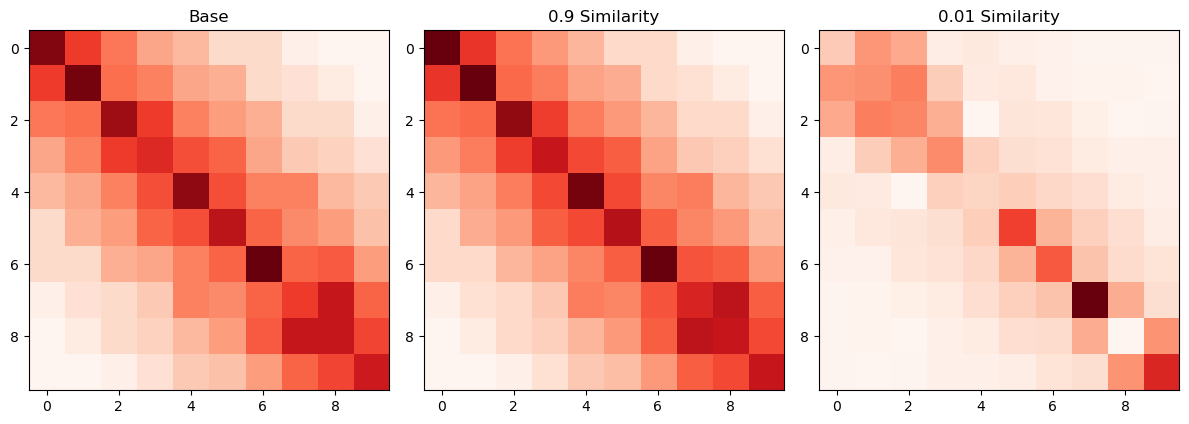

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'Base'}>,
        <Axes: title={'center': '0.9 Similarity'}>,
        <Axes: title={'center': '0.01 Similarity'}>], dtype=object))

In [2]:
### Visualizing random contact maps ###
import matplotlib.pyplot as plt

M1 = generate_contact_map()
M2 = generate_related_contact_map(M1, similarity=0.9)
M3 = generate_related_contact_map(M1, similarity=0.01)
maps = [M1, M2, M3]
titles = ["Base", "0.9 Similarity", "0.01 Similarity"]

visualize_synthetic_maps(maps, titles)

## Validating coordinate and mass approach
Before applying OT, we need a way to extract coordinates and masses in the same order. Thus, we'll validate the approach used for the large scale implementation here. This approach is as follows:
- Masking datasets to ensure only nonzero values and upper triangle.
- Extracting coordinates from mask using column stack.

[[ 80  34  19  10   4   2   1   0   0   0]
 [ 34  77  36  19  10   4   2   1   0   0]
 [ 19  36  89  37  19   9   4   2   1   0]
 [ 10  19  37  86  43  19   9   4   2   1]
 [  4  10  19  43  84  45  14   8   4   2]
 [  2   4   9  19  45  78  41  19   9   4]
 [  1   2   4   9  14  41  63  41  19   9]
 [  0   1   2   4   8  19  41 110  31  17]
 [  0   0   1   2   4   9  19  31  68  36]
 [  0   0   0   1   2   4   9  17  36  84]]
[[ 0 34 19 10  4  2  1  0  0  0]
 [ 0  0 36 19 10  4  2  1  0  0]
 [ 0  0  0 37 19  9  4  2  1  0]
 [ 0  0  0  0 43 19  9  4  2  1]
 [ 0  0  0  0  0 45 14  8  4  2]
 [ 0  0  0  0  0  0 41 19  9  4]
 [ 0  0  0  0  0  0  0 41 19  9]
 [ 0  0  0  0  0  0  0  0 31 17]
 [ 0  0  0  0  0  0  0  0  0 36]
 [ 0  0  0  0  0  0  0  0  0  0]]


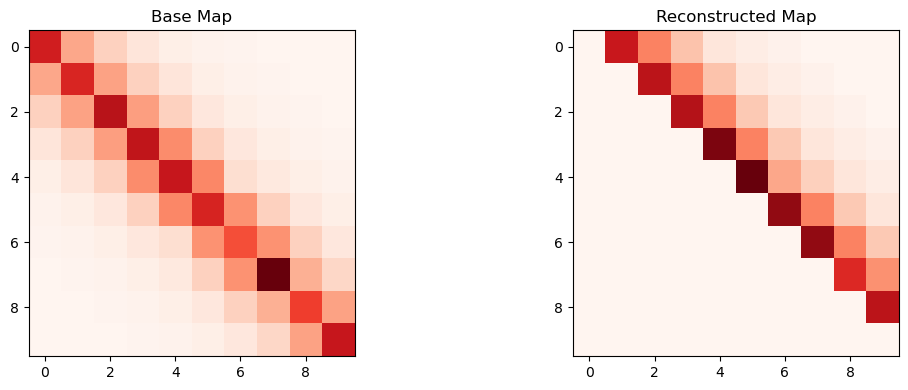

In [3]:
### Generating and visualizing data
base_map = generate_contact_map(decay_rate=0.75, seed=142)
dis_map = generate_related_contact_map(base_map, base_decay=0.75, similarity=0.01, seed=142)
print(base_map)

    # Defining masks
mask_base = np.triu(base_map, k=1) > 0

    # Pulling coordinates
base_coords = np.column_stack(np.where(mask_base))

    # Rebuild contact map from coords and mask
base_values = base_map[mask_base]
reconstructed = np.zeros_like(base_map)
reconstructed[tuple(base_coords.T)] = base_values
print(reconstructed)

    # Visualizing 
visualize_synthetic_maps([base_map, reconstructed], ["Base Map", "Reconstructed Map"])

    # Direct validation
i, j = base_coords.T
assert np.all(base_map[i, j] == base_values), "Coordinate/value mismatch detected!"

Examining the contact maps in data form, visually and even the explicit check seem to confirm that the coordinate approach is valid.

## Exact OT on Synthetic Contact Maps
To check the values of exact OT, we'll attempt to run OT between increasingly distinct contact maps. To facilitate this, we also need to normalize for difference in total read count, as the function defined above can give contact maps of unequal total count.

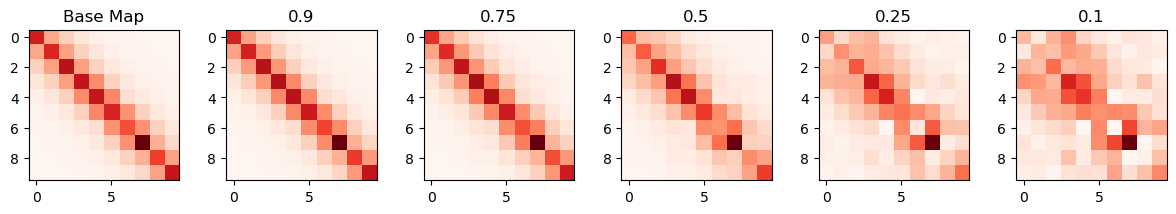

(<Figure size 1200x400 with 6 Axes>,
 array([<Axes: title={'center': 'Base Map'}>,
        <Axes: title={'center': '0.9'}>, <Axes: title={'center': '0.75'}>,
        <Axes: title={'center': '0.5'}>, <Axes: title={'center': '0.25'}>,
        <Axes: title={'center': '0.1'}>], dtype=object))

In [4]:
### Generating Data ###
base_map = generate_contact_map(decay_rate=0.75, seed=142)
similarity_list = [0.9, 0.75, 0.5, 0.25, 0.1]
target_maps = [base_map]

for sim in similarity_list:
    target_map = generate_related_contact_map(base_map, base_decay=0.75, similarity=sim, seed=142)
    target_maps.append(target_map)

# Visualizing maps
visualize_synthetic_maps(target_maps, ['Base Map'] + [float(sim) for sim in similarity_list])

In [5]:
### Prepping data for OT ###
# Base map
base_mask = np.triu(base_map, k=1) > 0
base_coords = np.column_stack(np.where(base_mask))
base_values = base_map[base_mask]

# Target maps
coords_list = []
values_list = []
for target in target_maps:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values = values * (base_values.sum() / values.sum()) # Normalizing to ensure equivalent weights
    print(values.sum())
    coords_list.append(coords)
    values_list.append(values)

591.0
591.0
591.0
591.0000000000001
591.0
591.0000000000001


In [6]:
### Exact OT for all target maps ###
import ot
ot_values = []
for coords, values in zip(coords_list, values_list):
    M = ot.dist(base_coords, coords)
    ot_value = ot.solve(M, base_values, values).value
    ot_values.append(ot_value)

/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/lp/_network_simplex.py:578: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)


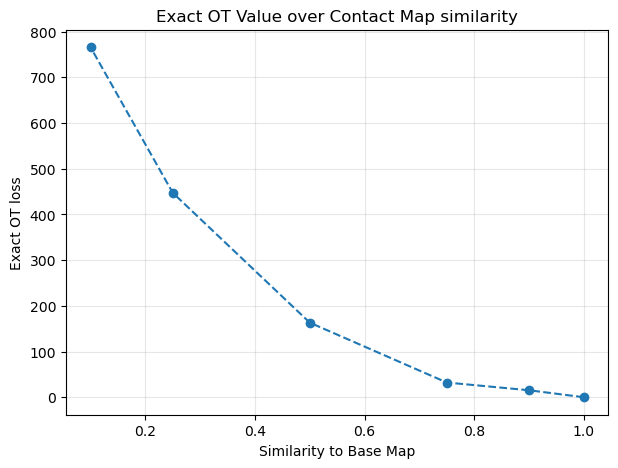

In [7]:
### Plotting results ###
plt.figure(figsize=(7, 5))
plt.plot([1.0] + similarity_list, ot_values, 'o--')
plt.xlabel("Similarity to Base Map")
plt.ylabel("Exact OT loss")
plt.title("Exact OT Value over Contact Map similarity")
plt.grid(alpha=0.3)
plt.show()

The graph here is intuitive, as the OT loss increases more as similarity to the base map decreases.

## Unbalanced OT on Synthetic Contact Matrices
Now that we've validated that exact OT works on simple contact maps, we'll validate if the same holds true for unbalanced optimal transport. Here, we'll test a few different things:
- OT value for decreasing similarity, as before.
- OT value for increasing mass ratio between source and target.
- OT value for a combination of decreasing similarity and increasing mass ratios.

### UOT for Decreasing Similarity

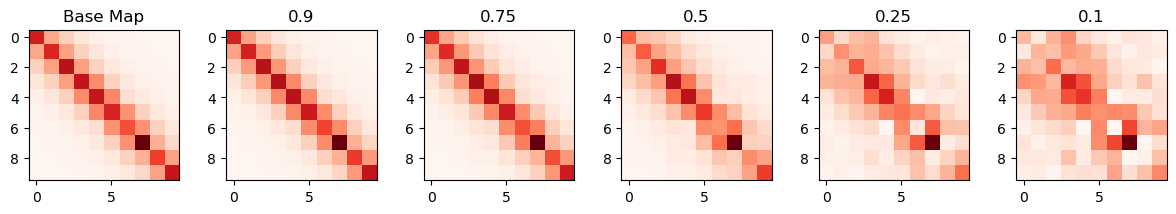

(<Figure size 1200x400 with 6 Axes>,
 array([<Axes: title={'center': 'Base Map'}>,
        <Axes: title={'center': '0.9'}>, <Axes: title={'center': '0.75'}>,
        <Axes: title={'center': '0.5'}>, <Axes: title={'center': '0.25'}>,
        <Axes: title={'center': '0.1'}>], dtype=object))

In [8]:
### Generating Data ###
base_map = generate_contact_map(decay_rate=0.75, seed=142)
similarity_list = [0.9, 0.75, 0.5, 0.25, 0.1]
target_maps = [base_map]

for sim in similarity_list:
    target_map = generate_related_contact_map(base_map, base_decay=0.75, similarity=sim, seed=142)
    target_maps.append(target_map)

# Visualizing maps
visualize_synthetic_maps(target_maps, ['Base Map'] + [float(sim) for sim in similarity_list])

In [9]:
### Prepping data for OT ###
# Base map
base_mask = np.triu(base_map, k=1) > 0
base_coords = np.column_stack(np.where(base_mask))
base_values = base_map[base_mask]

# Target maps
coords_list = []
values_list = [] # Also keep track of non-normalized maps to see if results differ much
values_list_norm = []
for target in target_maps:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values_norm = values * (base_values.sum() / values.sum()) # Normalizing to ensure equivalent weights
    print(values.sum())
    coords_list.append(coords)
    values_list.append(values)
    values_list_norm.append(values_norm)

591
593
612
666
746
803


In [10]:
### Exact OT for all target maps ###
import ot
unbalanced = 5e-1
ot_values = []
ot_values_norm= []

# UOT
for coords, values, values_norm in zip(coords_list, values_list, values_list_norm):
    M = ot.dist(base_coords, coords)
    ot_value = ot.solve(M, base_values, values, unbalanced=unbalanced).value
    ot_value_norm = ot.solve(M, base_values, values_norm, unbalanced=unbalanced).value
    ot_values.append(ot_value)
    ot_values_norm.append(ot_value_norm)

print(ot_values)
print(ot_values_norm)

[np.float64(9.64915717654892e-13), np.float64(0.035070326006847605), np.float64(0.4785804779493128), np.float64(8.869663559983202), np.float64(43.6842915788304), np.float64(82.04741074409728)]
[np.float64(9.64915717654892e-13), np.float64(0.03416796582206385), np.float64(0.3802311998974315), np.float64(7.300531226778192), np.float64(34.87007315359969), np.float64(63.4330240459055)]


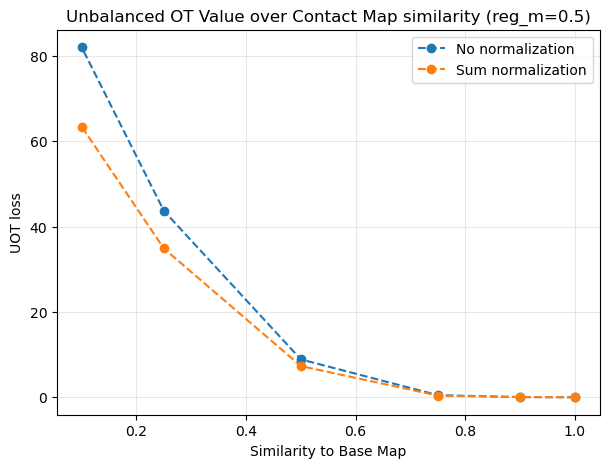

In [11]:
### Plotting ###
    # Non-normalized
plt.figure(figsize=(7, 5))
plt.plot([1.0] + similarity_list, ot_values, 'o--', label='No normalization')
plt.plot([1.0] + similarity_list, ot_values_norm, 'o--', label='Sum normalization')
plt.xlabel("Similarity to Base Map")
plt.ylabel("UOT loss")
plt.title(f"Unbalanced OT Value over Contact Map similarity (reg_m={unbalanced})")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Aside from the differing scale for the loss value, the overall graph looks very similar to the one for exact optimal transport. The effect of normalization also makes sense, as normalizing the mass to be identical makes the contact maps more similar.

### UOT for Differing Mass Ratios

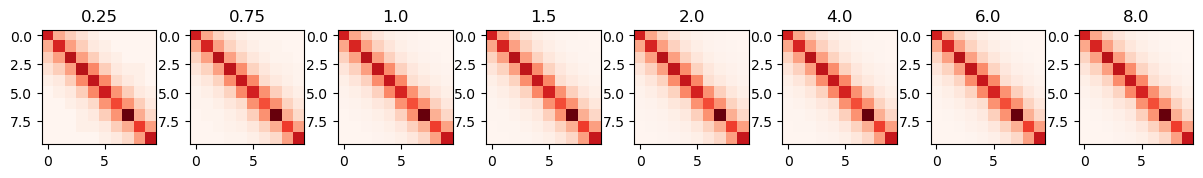

(<Figure size 1200x400 with 8 Axes>,
 array([<Axes: title={'center': '0.25'}>, <Axes: title={'center': '0.75'}>,
        <Axes: title={'center': '1.0'}>, <Axes: title={'center': '1.5'}>,
        <Axes: title={'center': '2.0'}>, <Axes: title={'center': '4.0'}>,
        <Axes: title={'center': '6.0'}>, <Axes: title={'center': '8.0'}>],
       dtype=object))

In [25]:
### Generating Data ###
base_map = generate_contact_map(decay_rate=0.75, seed=142)
mass_ratio_list = [0.25, 0.75, 1.0, 1.5, 2, 4, 6, 8]
target_maps = []

for ratio in mass_ratio_list:
    total_reads = 2000 * ratio
    target_map = generate_contact_map(decay_rate=0.75, seed=142, total_reads=total_reads)
    target_maps.append(target_map)

# Visualizing maps
visualize_synthetic_maps(target_maps, [float(ratio) for ratio in mass_ratio_list])

In [26]:
### Prepping data for OT ###
# Base map
base_mask = np.triu(base_map, k=1) > 0
base_coords = np.column_stack(np.where(base_mask))
base_values = base_map[base_mask]

# Target maps
coords_list = []
values_list = [] # Also keep track of non-normalized maps to see if results differ much
values_list_norm = []
for target in target_maps:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values_norm = values * (base_values.sum() / values.sum()) # Normalizing to ensure equivalent weights
    print(values.sum())
    coords_list.append(coords)
    values_list.append(values)
    values_list_norm.append(values_norm)

145
442
591
885
1184
2360
3544
4724


In [27]:
### Exact OT for all target maps ###
import ot
unbalanced = 5e-1
ot_values = []
ot_values_norm= []

# UOT
for coords, values, values_norm in zip(coords_list, values_list, values_list_norm):
    M = ot.dist(base_coords, coords)
    ot_value = ot.solve(M, base_values, values, unbalanced=unbalanced).value
    ot_value_norm = ot.solve(M, base_values, values_norm, unbalanced=unbalanced).value
    ot_values.append(ot_value)
    ot_values_norm.append(ot_value_norm)

print(ot_values)
print(ot_values_norm)

[np.float64(78.10358679078522), np.float64(5.624180453462127), np.float64(9.64915717654892e-13), np.float64(15.938513881601779), np.float64(51.987974931064386), np.float64(296.16220081038), np.float64(622.379032673935), np.float64(989.2898814221173)]
[np.float64(5.734962122720297), np.float64(0.2578582920759885), np.float64(9.64915717654892e-13), np.float64(0.9398491509662165), np.float64(0.7029755011191531), np.float64(0.8315925650093586), np.float64(0.8653894827841814), np.float64(0.9490049812127542)]


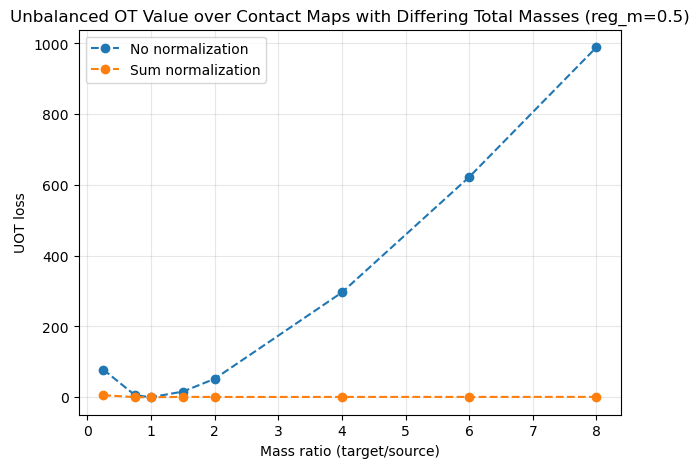

In [28]:
### Plotting ###
plt.figure(figsize=(7, 5))
plt.plot(mass_ratio_list, ot_values, 'o--', label='No normalization')
plt.plot(mass_ratio_list, ot_values_norm, 'o--', label='Sum normalization')
plt.xlabel("Mass ratio (target/source)")
plt.ylabel("UOT loss")
plt.title(f"Unbalanced OT Value over Contact Maps with Differing Total Masses (reg_m={unbalanced})")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Unlike the values for the simple data tests, these values make a lot of sense. The UOT loss keeps increasing the more the mass ratio deviates from 0. With normalization, the UOT loss remains at (roughly) 0.

### UOT for Increasing Mass Ratio and Decreasing Similarity

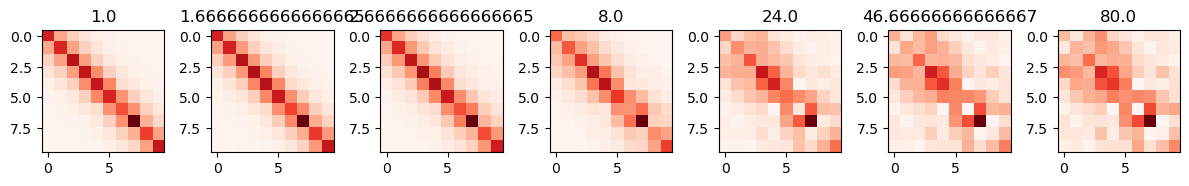

(<Figure size 1200x400 with 7 Axes>,
 array([<Axes: title={'center': '1.0'}>,
        <Axes: title={'center': '1.6666666666666665'}>,
        <Axes: title={'center': '2.6666666666666665'}>,
        <Axes: title={'center': '8.0'}>, <Axes: title={'center': '24.0'}>,
        <Axes: title={'center': '46.66666666666667'}>,
        <Axes: title={'center': '80.0'}>], dtype=object))

In [16]:
### Generating Data ###
base_map = generate_contact_map(decay_rate=0.75, seed=142)
mass_ratio_list = [1.5, 2.0, 4.0, 6.0, 7.0, 8.0]
similarity_list = [0.9, 0.75, 0.5, 0.25, 0.15, 0.1]
mass_sim_list = [1.0]
target_maps = [base_map]

# Generating target maps
for ratio, sim in zip(mass_ratio_list, similarity_list):
    total_reads = 2000 * ratio
    mass_sim = ratio/sim
    target_map_base = generate_contact_map(decay_rate=0.75, seed=142, total_reads=total_reads)
    target_map = generate_related_contact_map(target_map_base, base_decay=0.75, similarity=sim, seed=142)
    mass_sim_list.append(mass_sim)
    target_maps.append(target_map)

# Visualizing maps
visualize_synthetic_maps(target_maps, [float(mass_sim) for mass_sim in mass_sim_list])

In [17]:
### Prepping data for OT ###
# Base map
base_mask = np.triu(base_map, k=1) > 0
base_coords = np.column_stack(np.where(base_mask))
base_values = base_map[base_mask]

# Target maps
coords_list = []
values_list = [] # Also keep track of non-normalized maps to see if results differ much
values_list_norm = []
for target in target_maps:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values_norm = values * (base_values.sum() / values.sum()) # Normalizing to ensure equivalent weights
    print(values.sum())
    coords_list.append(coords)
    values_list.append(values)
    values_list_norm.append(values_norm)

591
891
1227
2656
4471
5490
6427


In [18]:
### Exact OT for all target maps ###
import ot
unbalanced = 5e-1
ot_values = []
ot_values_norm= []

# UOT
for coords, values, values_norm in zip(coords_list, values_list, values_list_norm):
    M = ot.dist(base_coords, coords)
    ot_value = ot.solve(M, base_values, values, unbalanced=unbalanced).value
    ot_value_norm = ot.solve(M, base_values, values_norm, unbalanced=unbalanced).value
    ot_values.append(ot_value)
    ot_values_norm.append(ot_value_norm)

print(ot_values)
print(ot_values_norm)

[np.float64(9.64915717654892e-13), np.float64(16.52525933520447), np.float64(59.01514638186768), np.float64(386.9708436493716), np.float64(1002.590534770774), np.float64(1404.056434825747), np.float64(1771.2505748527751)]
[np.float64(9.64915717654892e-13), np.float64(0.9645076512365031), np.float64(1.094227569384985), np.float64(7.710624088334779), np.float64(35.31186476056085), np.float64(54.081212308621204), np.float64(64.04109983678262)]


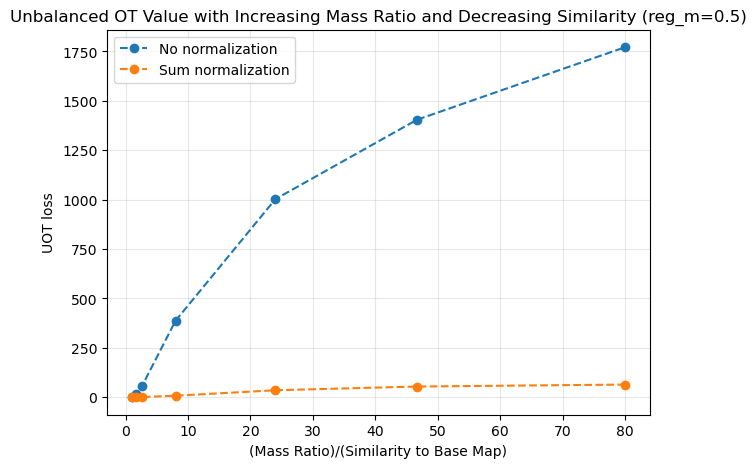

In [19]:
### Plotting ###
plt.figure(figsize=(7, 5))
plt.plot(mass_sim_list, ot_values, 'o--', label='No normalization')
plt.plot(mass_sim_list, ot_values_norm, 'o--', label='Sum normalization')
plt.xlabel("(Mass Ratio)/(Similarity to Base Map)")
plt.ylabel("UOT loss")
plt.title(f"Unbalanced OT Value with Increasing Mass Ratio and Decreasing Similarity (reg_m={unbalanced})")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Combining increasing mass ratios and decreasing similarity also shows no saturation just yet. However, the graph is starting to plateau.

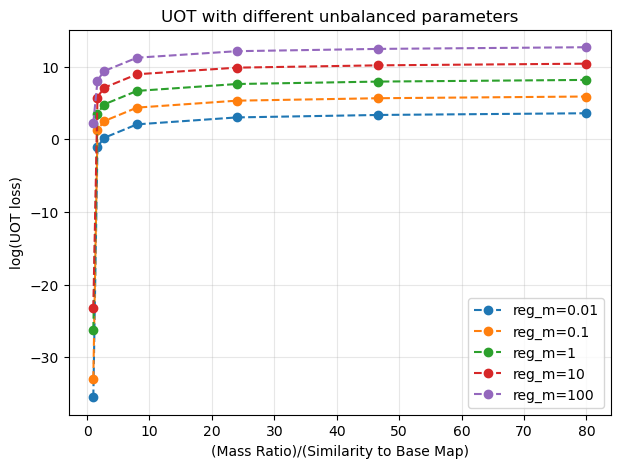

In [24]:
### Investigating Unbalanced Parameter ###
unbalanced_list = [1e-2, 1e-1, 1, 10, 100]

# OT for unbalanced parameters
ot_series = []

for reg_m in unbalanced_list:
    ot_values = []

    for coords, values, values_norm in zip(coords_list, values_list, values_list_norm):
        M = ot.dist(base_coords, coords)
        ot_value = ot.solve(M, base_values, values, unbalanced=reg_m).value
        ot_values.append(ot_value)
    
    ot_series.append(ot_values)

# Plotting
plt.figure(figsize=(7, 5))
for ot_values, reg_m in zip(ot_series, unbalanced_list):
    plt.plot(mass_sim_list, np.log(ot_values), 'o--', label=f'reg_m={reg_m}')
plt.xlabel("(Mass Ratio)/(Similarity to Base Map)")
plt.ylabel("log(UOT loss)")
plt.title(f"UOT with different unbalanced parameters")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Even with quite different reg_m values, the shapes of the OT loss graphs are identical, indicating that these datasets seem to be sufficiently complex to prevent UOT saturation.